--- Dataset Head ---
          Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0    Ford EcoSport  2014      19.514745      24.993517       84910    Petrol   
1       Honda City  2017      16.219015      20.960325       62375    Petrol   
2  Toyota Fortuner  2022       4.325822      17.122766      131826    Petrol   
3       Honda City  2010       3.934457      12.688423       45435       CNG   
4       Honda City  2014      18.122290      26.684415      106443    Diesel   

  Transmission  Car_Age  
0    Automatic       12  
1       Manual        9  
2       Manual        4  
3    Automatic       16  
4       Manual       12  


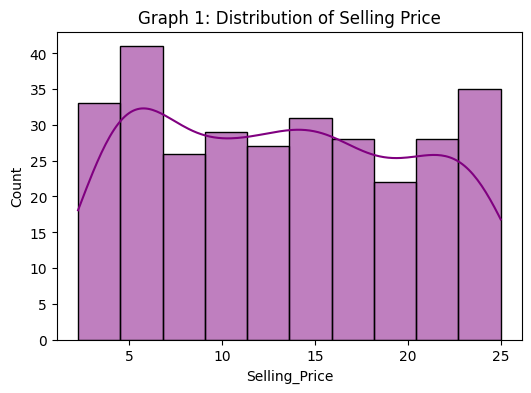

/tmp/ipykernel_2238/3803484113.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')


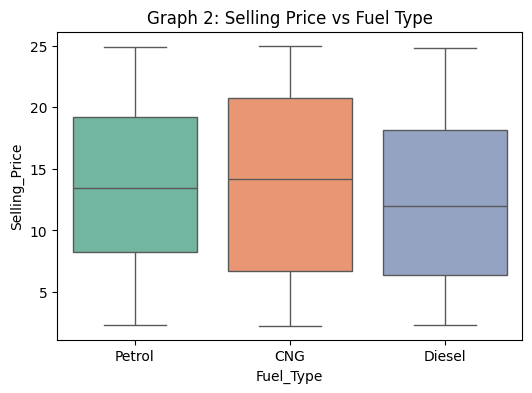

/tmp/ipykernel_2238/3803484113.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='Set1')


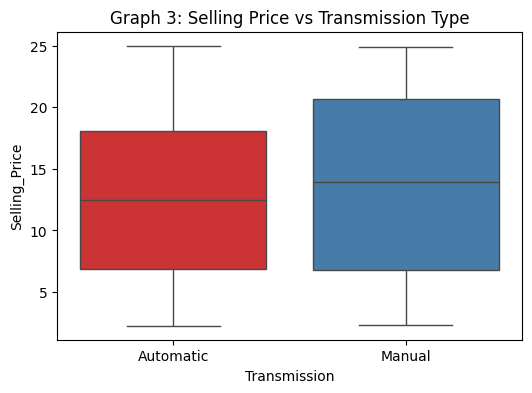

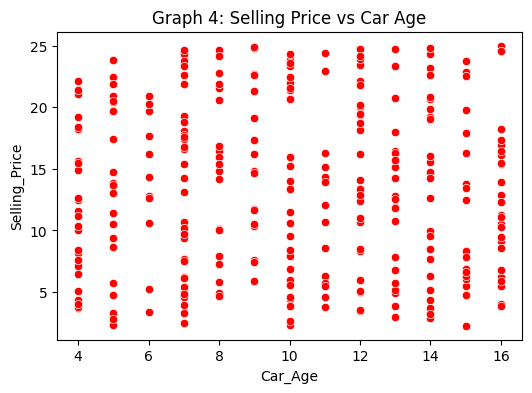

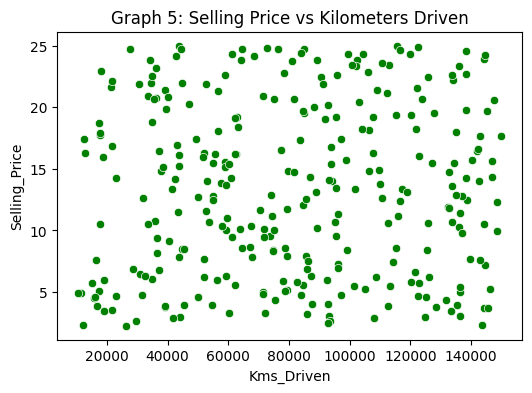

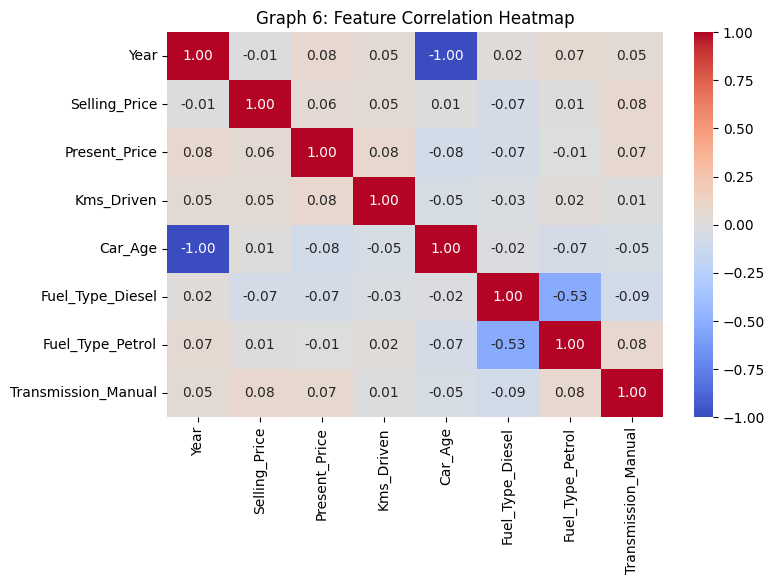


--- Model Evaluation Results ---
Mean Absolute Error (MAE): 6.65
Root Mean Squared Error (RMSE): 7.59
R² Score: -0.20


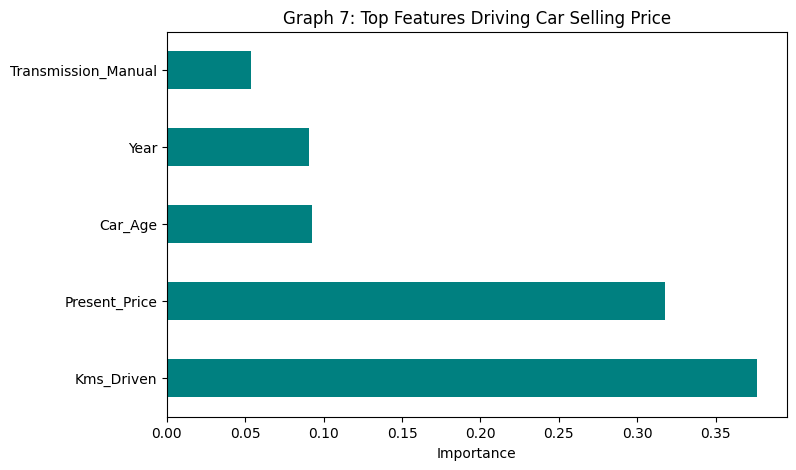

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1: Create Dataset
np.random.seed(42)
n_samples = 300

data = {
    'Car_Name': np.random.choice(['Maruti 800', 'Hyundai Verna', 'Toyota Fortuner', 'Ford EcoSport', 'Honda City'], n_samples),
    'Year': np.random.randint(2010, 2023, n_samples),
    'Selling_Price': np.random.uniform(2.0, 25.0, n_samples),
    'Present_Price': np.random.uniform(3.0, 30.0, n_samples),
    'Kms_Driven': np.random.randint(10000, 150000, n_samples),
    'Fuel_Type': np.random.choice(['Petrol', 'Diesel', 'CNG'], n_samples),
    'Transmission': np.random.choice(['Manual', 'Automatic'], n_samples)
}

df = pd.DataFrame(data)

# Step 2: Feature Engineering (Car Age)
df['Car_Age'] = 2026 - df['Year']

print("--- Dataset Head ---")
print(df.head())

# ==========================================
# 7 VISUALIZATION GRAPHS
# ==========================================

# Graph 1: Distribution of Selling Prices
plt.figure(figsize=(6, 4))
sns.histplot(df['Selling_Price'], kde=True, color='purple')
plt.title('Graph 1: Distribution of Selling Price')
plt.show()

# Graph 2: Price vs Fuel Type Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title('Graph 2: Selling Price vs Fuel Type')
plt.show()

# Graph 3: Price vs Transmission Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='Set1')
plt.title('Graph 3: Selling Price vs Transmission Type')
plt.show()

# Graph 4: Price vs Car Age Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df, color='red')
plt.title('Graph 4: Selling Price vs Car Age')
plt.show()

# Graph 5: Price vs Kilometers Driven Scatter Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df, color='green')
plt.title('Graph 5: Selling Price vs Kilometers Driven')
plt.show()

# One-Hot Encoding for Heatmap & Machine Learning Models
df_encoded = pd.get_dummies(df.drop(columns=['Car_Name']), drop_first=True).astype(float)

# Graph 6: Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Graph 6: Feature Correlation Heatmap')
plt.show()

# ==========================================
# MACHINE LEARNING MODEL TRAINING
# ==========================================

X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Model Evaluation Results ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

# Graph 7: Feature Importance Chart
plt.figure(figsize=(8, 5))
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Graph 7: Top Features Driving Car Selling Price')
plt.xlabel('Importance')
plt.show()